<a href="https://colab.research.google.com/github/Aarya-Musale/Machine-Learning/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw/aaecbd14aeaa468cd749528f291aa8a30c2ea09e/iris_dataset.csv')

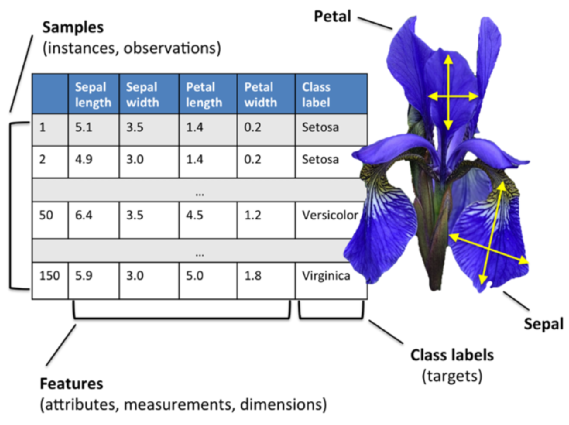

In [ ]:
data.head()

In [ ]:
data.info()

In [ ]:
data[:2]

In [ ]:
data.values[:3] # .values convert ur df into array

In [ ]:
X = data.iloc[:,:-1]

In [ ]:
y = data.iloc[:,4]

## Split the data

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.20)

In [ ]:
X_train[:3]

In [ ]:
data.describe().T

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.neighbors import KNeighborsRegressor

In [ ]:
y.unique()

In [ ]:
# default value of neighbours: n_neighbors=5
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.score(X_train,y_train)*100

In [ ]:
knn.score(X_test,y_test)*100

In [ ]:
# TEstting phase
y_pred = knn.predict(X_test)
y_pred

In [ ]:
# check actual and predicted result
display(y_test.values,y_pred)

In [ ]:
#print('Accuracy is:',model.score(X_train,y_train))#98.33
print('Accuracy is:',knn.score(X_test,y_pred))# for predicted output accuracy is always 100

Data Score- Input + Output

Model score- Actual_output + Predicted_output

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))

In [ ]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,
           xticklabels=['setosa','versicolor','verginica'],yticklabels=['setosa','versicolor','verginica'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
# check actual records of class 0
sum(y_test == 'Iris-setosa')

In [ ]:
#actual
sum(y_test == 'Iris-versicolor')

In [ ]:
#predicted
sum(y_pred == 'Iris-versicolor')

In [ ]:
#actual virginica
sum(y_test=='virginica')

In [ ]:
sum(y_pred=='virginica')

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
# model's accuracy
print(accuracy_score(y_test,y_pred)*100)

# Find out value of K?

In [ ]:
KNeighborsClassifier?

In [ ]:
[i for i in range(1,11)]  # k value generation

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

# We are going to use a precision metric as a measure for selection crieteria of K

In [ ]:
for i in range(1,11):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print('for k value:',i,'precision is:',precision_score(y_test,y_pred,average='weighted'))

In [ ]:
from sklearn.metrics import f1_score,confusion_matrix,roc_auc_score
f1_list=[]  # list for f1_score
k_list=[] # list for K value
for k in range(1,11):
    clf=KNeighborsClassifier(n_neighbors=k,n_jobs=-1)
    clf.fit(X_train,y_train)
    pred=clf.predict(X_test)
    f=f1_score(y_test,pred,average='macro')
    f1_list.append(f)
    k_list.append(k)

In [ ]:
#number of clusters
k_list

In [ ]:
# f1_score for clusters 1-10
print(f1_list)

In [ ]:
max(f1_list)

In [ ]:
f1_list.index(1.0)

In [ ]:
k_list

In [ ]:
best_f1_score=max(f1_list)
best_k=k_list[f1_list.index(best_f1_score)]
print("Optimum K value=",best_k," with F1-Score=",best_f1_score)

In [ ]:
scor = [0.919047619047619, 0.8754578754578755, 0.919047619047619, 0.8282828282828283, 0.9602339181286549, 0.8282828282828283, 0.919047619047619, 0.8754578754578755, 0.8754578754578755, 0.8754578754578755]
len(scor)

In [ ]:
k_list

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(k_list,scor,'r--o')
plt.title('K neigbours vs f1_score')

In [ ]:
plt.plot(k_list,f1_list,'r--o')
plt.title('K neigbours vs f1_score')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier(n_neighbors=5)
model_2.fit(X_train,y_train)

In [ ]:
model_2.score(X_train,y_train)*100

# Check  K vs error rate

In [ ]:
y_test.values

In [ ]:
y_1 = 'setosa'
pr = 'versicolor'

In [ ]:
y_1 != pr

In [ ]:
np.mean([True,False,True,False])

In [ ]:
error_rate = []
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [ ]:
pred_i != y_test

In [ ]:
print(error_rate)

In [ ]:
k_list

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,21),error_rate,color='blue', linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at k =",k_list[error_rate.index(min(error_rate))])

# Find out k using precision

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
p = []
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    p.append(precision_score(y_test,pred_i,average='macro'))

In [ ]:
print(p)

In [ ]:
plt.plot(range(1,21),p,'--r')
plt.xlim((2,20))
plt.grid()

# finding the K value

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import recall_score

In [ ]:
pr_score = []
for i in range(1,16): #k value [1-15]
    model_1 = KNeighborsClassifier(n_neighbors=i,n_jobs=-1)
    #training
    model_1.fit(X_train,y_train)
    ypred = model_1.predict(X_test)
    p_score = recall_score(y_test,ypred,average='macro')
    print('Recall for k:',i,'is:',round(p_score*100,2))
    pr_score.append(p_score)

In [ ]:
print(pr_score)

In [ ]:
plt.plot(range(1,16),pr_score,'--Dr')

## Assignment: Use Social_network data and apply KNN, Find best suitable K value

In [ ]:
s = pd.read_csv('Social_Net_class.csv')
s.head()

In [ ]:
s.Purchased.unique()

In [ ]:
# binary classification problem: We need to build a ML model which can predict either a person will buy or not on the
# basis of 3 features Gender Age and EstimatedSalary

In [ ]:
# delete user id column
s.drop(columns=['User ID'],inplace=True)

In [ ]:
# convert Gender into numbers
s['Gender'] = s['Gender'].map({'Male':0,'Female':1})

In [ ]:
s